In [1]:
# Import the function to load datasets
from sklearn.datasets import fetch_openml

# Fetch the UCI HAR dataset from OpenML
har = fetch_openml(name="har", version=1, as_frame=True)

# Extract features and target
X, y = har.data, har.target.astype(int)


In [2]:
print(X.shape)       # Should print (10299, 561)
print(y.shape)       # Should print (10299,)
print(y.unique())    # Should print [1, 2, 3, 4, 5, 6]
print(X.head())      # First few rows of the features


(10299, 561)
(10299,)
[5 4 6 1 3 2]
         V1        V2        V3        V4        V5        V6        V7  \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

         V8        V9       V10  ...      V552      V553      V554      V555  \
0 -0.983185 -0.923527 -0.934724  ... -0.074323 -0.298676 -0.710304 -0.112754   
1 -0.974914 -0.957686 -0.943068  ...  0.158075 -0.595051 -0.861499  0.053477   
2 -0.963668 -0.977469 -0.938692  ...  0.414503 -0.390748 -0.760104 -0.118559   
3 -0.982750 -0.989303 -0.938692  ...  0.404573 -0.117290 -0.482845 -0.036788   
4 -0.979672 -0.990441 -0.942469  ...  0.087753 -0.351471 -0.699205  0.123320   

       V556      V557      V558 

In [3]:
import numpy as np

# Check for missing values in the entire dataset
missing_values = X.isnull().sum().sum()
print("Total missing values in dataset:", missing_values)

# Check data types — should be all numeric (float64 ideally)
print("\nFeature data types count:")
print(X.dtypes.value_counts())

# Outlier detection using z-scores (values > 3 std devs from mean)
z_scores = np.abs((X - X.mean()) / X.std())
outlier_count = (z_scores > 3).sum().sum()
print("\nEstimated number of outlier values (z-score > 3):", outlier_count)


Total missing values in dataset: 0

Feature data types count:
float64    561
Name: count, dtype: int64

Estimated number of outlier values (z-score > 3): 56270


In [4]:
# Combine features and labels into one DataFrame for grouped analysis
df = X.copy()
df["activity"] = y

# Compute class-wise mean for all 561 features
classwise_means = df.groupby("activity").mean()

# Preview: show means of first 5 features for each class
print("Class-wise means of the first 5 features:")
print(classwise_means.iloc[:, :5].round(3))


Class-wise means of the first 5 features:
             V1     V2     V3     V4     V5
activity                                   
1         0.276 -0.018 -0.109 -0.315 -0.024
2         0.262 -0.026 -0.121 -0.238 -0.016
3         0.288 -0.016 -0.106  0.101  0.060
4         0.273 -0.013 -0.106 -0.983 -0.935
5         0.279 -0.016 -0.107 -0.984 -0.933
6         0.269 -0.018 -0.107 -0.961 -0.944


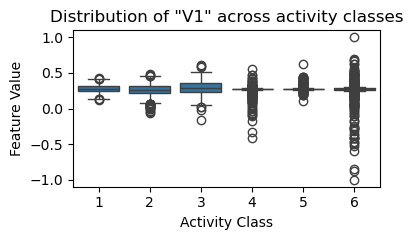

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Pick one high-importance feature
feature = X.columns[0]  # You can replace this with a more relevant one later

plt.figure(figsize=(4,2.5))
sns.boxplot(x=y, y=X[feature])
plt.title(f'Distribution of "{feature}" across activity classes')
plt.xlabel("Activity Class")
plt.ylabel("Feature Value")
plt.tight_layout()
plt.show()


In [6]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)

# Step 2: Convert to Pandas Series for easy sorting
mi_series = pd.Series(mi_scores, index=X.columns)

# Step 3: Sort and select top 10 features
top_10_features = mi_series.sort_values(ascending=False).head(10)
print("Top 10 features most informative about the target classes:")
print(top_10_features)


Top 10 features most informative about the target classes:
V10     0.997349
V90     0.928200
V204    0.914082
V217    0.914013
V91     0.887195
V303    0.886498
V311    0.880392
V54     0.879674
V230    0.878853
V13     0.871894
dtype: float64


C:\Users\Aayushi Jha\AppData\Local\Temp\ipykernel_100504\979075209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")


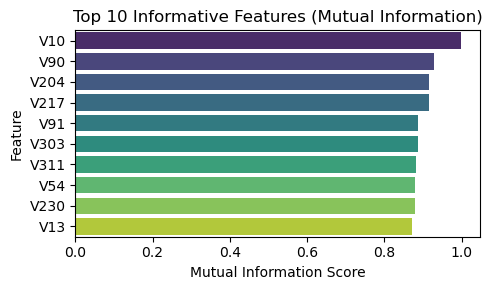

In [7]:
# Step 4: Visualize top 10 features
plt.figure(figsize=(5, 3))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")
plt.title("Top 10 Informative Features (Mutual Information)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
import numpy as np

# Store results
rf_accuracies = []
rf_f1s = []
rf_aucs = []

# Make y binary for AUC-ROC (one-hot encoded)
y_binarized = label_binarize(y, classes=[1, 2, 3, 4, 5, 6])

# 5 runs with different seeds
for seed in [0, 1, 2, 3, 4]:
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

    # Standardize (fit only on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    rf = RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=20)
    rf.fit(X_train_scaled, y_train)

    # Predict
    y_pred = rf.predict(X_test_scaled)
    y_prob = rf.predict_proba(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6]), y_prob, multi_class='ovr')

    rf_accuracies.append(acc)
    rf_f1s.append(f1)
    rf_aucs.append(auc)

# Results
print("Random Forest Performance over 5 runs:")
print(f"Accuracy: {np.mean(rf_accuracies):.4f} ± {np.std(rf_accuracies):.4f}")
print(f"F1 Score: {np.mean(rf_f1s):.4f} ± {np.std(rf_f1s):.4f}")
print(f"AUC-ROC:  {np.mean(rf_aucs):.4f} ± {np.std(rf_aucs):.4f}")


Random Forest Performance over 5 runs:
Accuracy: 0.9771 ± 0.0047
F1 Score: 0.9769 ± 0.0047
AUC-ROC:  0.9994 ± 0.0001


In [9]:
from sklearn.neural_network import MLPClassifier

# Store metrics
nn_accuracies = []
nn_f1s = []
nn_aucs = []

# Loop over 5 random seeds
for seed in [0, 1, 2, 3, 4]:
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

    # Standardize (very important for neural nets!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train MLP (2 hidden layers: 64 and 32 neuros)
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=seed)
    mlp.fit(X_train_scaled, y_train)

    # Predict
    y_pred = mlp.predict(X_test_scaled)
    y_prob = mlp.predict_proba(X_test_scaled)
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6]), y_prob, multi_class='ovr')

    # Store
    nn_accuracies.append(acc)
    nn_f1s.append(f1)
    nn_aucs.append(auc)

# Display results
print("Neural Network Performance over 5 runs:")
print(f"Accuracy: {np.mean(nn_accuracies):.4f} ± {np.std(nn_accuracies):.4f}")
print(f"F1 Score: {np.mean(nn_f1s):.4f} ± {np.std(nn_f1s):.4f}")
print(f"AUC-ROC:  {np.mean(nn_aucs):.4f} ± {np.std(nn_aucs):.4f}")


Neural Network Performance over 5 runs:
Accuracy: 0.9851 ± 0.0029
F1 Score: 0.9857 ± 0.0027
AUC-ROC:  0.9994 ± 0.0003


In [10]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode y (to get binary class indicators)
y_onehot = OneHotEncoder(sparse_output=False).fit_transform(np.array(y).reshape(-1, 1))

# Compute correlation between each feature and each class column
correlations = []

for col in X.columns:
    feature_vals = X[col].values
    corr_with_classes = [np.corrcoef(feature_vals, y_onehot[:, i])[0, 1] for i in range(6)]
    max_corr = max([abs(c) for c in corr_with_classes])
    correlations.append(max_corr)

# Convert to Series and sort
corr_series = pd.Series(correlations, index=X.columns).sort_values(ascending=False)

# Preview top 10 correlated features
print("Top 10 features most correlated with target (by max abs correlation across classes):")
print(corr_series.head(10))


Top 10 features most correlated with target (by max abs correlation across classes):
V41     0.977198
V53     0.976044
V50     0.974782
V57     0.971486
V559    0.959554
V58     0.827713
V51     0.788558
V560    0.788323
V42     0.787068
V54     0.784160
dtype: float64


In [11]:
# Ensure we have corr_series from Task 4 Part 1
# corr_series = pd.Series(correlations, index=X.columns).sort_values(ascending=False)

k_values = [100, 200, 300, 400, 500]
acc_list, f1_list, auc_list = [], [], []

for k in k_values:
    top_k_features = corr_series.head(k).index
    X_k = X[top_k_features]

    acc_runs, f1_runs, auc_runs = [], [], []

    for seed in [0, 1, 2, 3, 4]:
        X_train, X_test, y_train, y_test = train_test_split(X_k, y, test_size=0.2, stratify=y, random_state=seed)

        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Neural Net (same as Part 3)
        clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=seed)
        clf.fit(X_train_scaled, y_train)

        # Predictions
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)

        # Metrics
        acc_runs.append(accuracy_score(y_test, y_pred))
        f1_runs.append(f1_score(y_test, y_pred, average='macro'))
        auc_runs.append(roc_auc_score(label_binarize(y_test, classes=[1,2,3,4,5,6]), y_prob, multi_class='ovr'))

    # Store mean & std for this k
    acc_list.append((np.mean(acc_runs), np.std(acc_runs)))
    f1_list.append((np.mean(f1_runs), np.std(f1_runs)))
    auc_list.append((np.mean(auc_runs), np.std(auc_runs)))


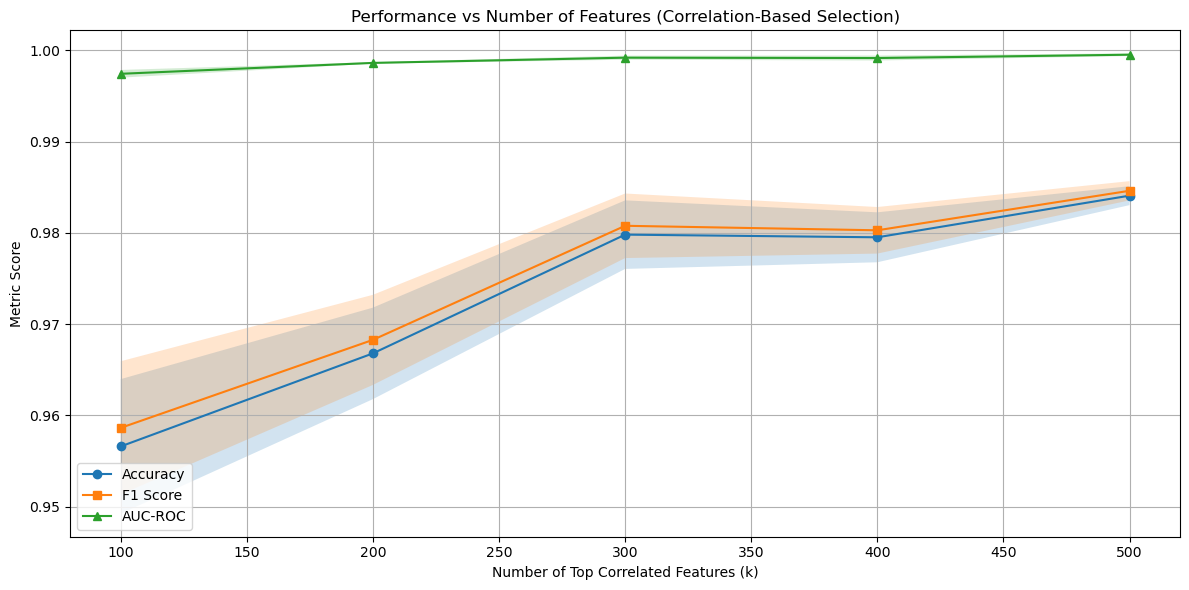

In [12]:
# Unpack results
acc_mean, acc_std = zip(*acc_list)
f1_mean, f1_std = zip(*f1_list)
auc_mean, auc_std = zip(*auc_list)

plt.figure(figsize=(12, 6))

# Accuracy
plt.plot(k_values, acc_mean, marker='o', label='Accuracy')
plt.fill_between(k_values, np.array(acc_mean)-np.array(acc_std), np.array(acc_mean)+np.array(acc_std), alpha=0.2)

# F1 Score
plt.plot(k_values, f1_mean, marker='s', label='F1 Score')
plt.fill_between(k_values, np.array(f1_mean)-np.array(f1_std), np.array(f1_mean)+np.array(f1_std), alpha=0.2)

# AUC
plt.plot(k_values, auc_mean, marker='^', label='AUC-ROC')
plt.fill_between(k_values, np.array(auc_mean)-np.array(auc_std), np.array(auc_mean)+np.array(auc_std), alpha=0.2)

plt.xlabel("Number of Top Correlated Features (k)")
plt.ylabel("Metric Score")
plt.title("Performance vs Number of Features (Correlation-Based Selection)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


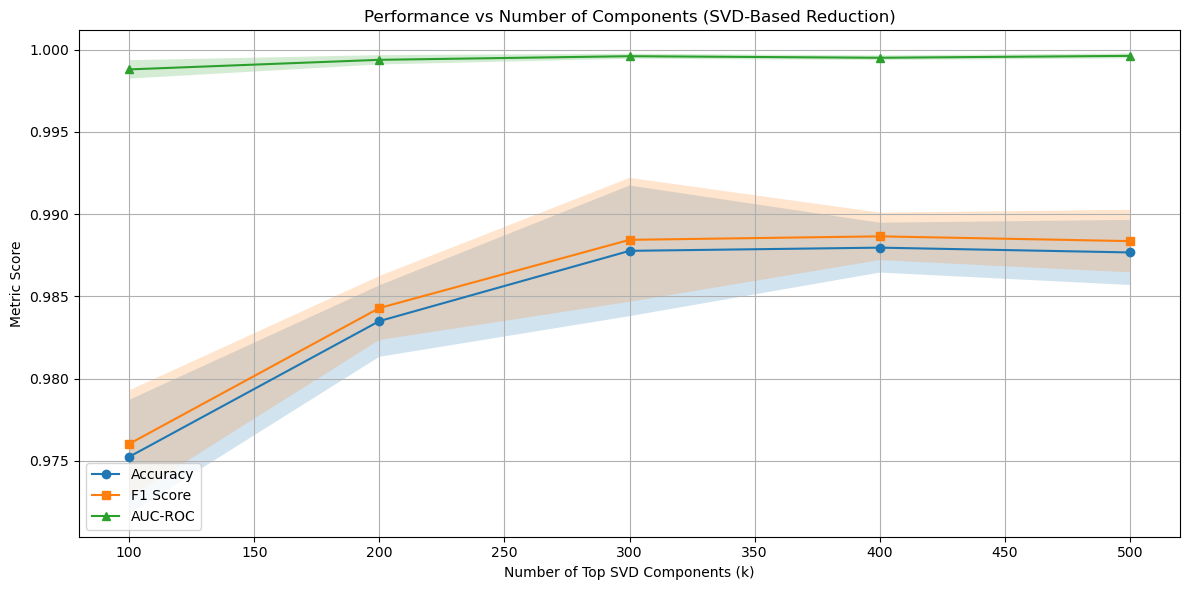

In [13]:
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Standardize and center X
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

# Step 2: Compute covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

# Step 3: Eigen decomposition (equivalent to SVD for symmetric matrix)
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# Step 4: Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# Store results
k_values = [100, 200, 300, 400, 500]
acc_list, f1_list, auc_list = [], [], []

for k in k_values:
    # Take top k eigenvectors
    U_k = eig_vecs[:, :k]
    
    # Project data
    X_reduced = X_scaled @ U_k
    
    acc_runs, f1_runs, auc_runs = [], [], []
    
    for seed in [0, 1, 2, 3, 4]:
        X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, stratify=y, random_state=seed)
        
        # Train NN
        clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=seed)
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        
        acc_runs.append(accuracy_score(y_test, y_pred))
        f1_runs.append(f1_score(y_test, y_pred, average='macro'))
        auc_runs.append(roc_auc_score(label_binarize(y_test, classes=[1,2,3,4,5,6]), y_prob, multi_class='ovr'))
    
    acc_list.append((np.mean(acc_runs), np.std(acc_runs)))
    f1_list.append((np.mean(f1_runs), np.std(f1_runs)))
    auc_list.append((np.mean(auc_runs), np.std(auc_runs)))

# Step 5: Plot
acc_mean, acc_std = zip(*acc_list)
f1_mean, f1_std = zip(*f1_list)
auc_mean, auc_std = zip(*auc_list)

plt.figure(figsize=(12, 6))
plt.plot(k_values, acc_mean, marker='o', label='Accuracy')
plt.fill_between(k_values, np.array(acc_mean)-np.array(acc_std), np.array(acc_mean)+np.array(acc_std), alpha=0.2)

plt.plot(k_values, f1_mean, marker='s', label='F1 Score')
plt.fill_between(k_values, np.array(f1_mean)-np.array(f1_std), np.array(f1_mean)+np.array(f1_std), alpha=0.2)

plt.plot(k_values, auc_mean, marker='^', label='AUC-ROC')
plt.fill_between(k_values, np.array(auc_mean)-np.array(auc_std), np.array(auc_mean)+np.array(auc_std), alpha=0.2)

plt.xlabel("Number of Top SVD Components (k)")
plt.ylabel("Metric Score")
plt.title("Performance vs Number of Components (SVD-Based Reduction)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# these are from Task 5 (current values in memory)
acc_list_svd = acc_list.copy()
f1_list_svd  = f1_list.copy()
auc_list_svd = auc_list.copy()


In [15]:
k_values = [100, 200, 300, 400, 500]
acc_list, f1_list, auc_list = [], [], []   # reset

for k in k_values:
    top_k_features = corr_series.head(k).index
    X_k = X[top_k_features]

    acc_runs, f1_runs, auc_runs = [], [], []
    for seed in [0,1,2,3,4]:
        X_train, X_test, y_train, y_test = train_test_split(X_k, y, test_size=0.2, stratify=y, random_state=seed)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        clf = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', max_iter=300, random_state=seed)
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s); y_prob = clf.predict_proba(X_test_s)

        acc_runs.append(accuracy_score(y_test, y_pred))
        f1_runs.append(f1_score(y_test, y_pred, average='macro'))
        auc_runs.append(roc_auc_score(label_binarize(y_test, classes=[1,2,3,4,5,6]), y_prob, multi_class='ovr'))

    acc_list.append((np.mean(acc_runs), np.std(acc_runs)))
    f1_list.append((np.mean(f1_runs), np.std(f1_runs)))
    auc_list.append((np.mean(auc_runs), np.std(auc_runs)))

# save as Task 4 results
acc_list_corr, f1_list_corr, auc_list_corr = acc_list.copy(), f1_list.copy(), auc_list.copy()


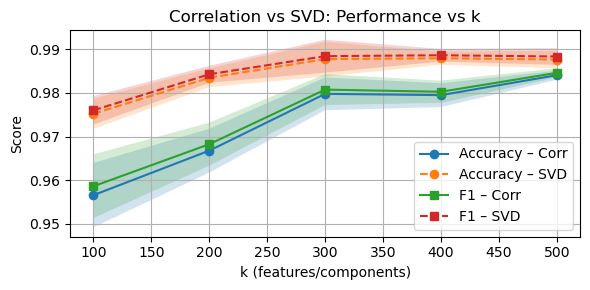

In [16]:
acc_corr_mean, acc_corr_std = zip(*acc_list_corr)
f1_corr_mean,  f1_corr_std  = zip(*f1_list_corr)

acc_svd_mean,  acc_svd_std  = zip(*acc_list_svd)
f1_svd_mean,   f1_svd_std   = zip(*f1_list_svd)

plt.figure(figsize=(6,3))
plt.plot(k_values, acc_corr_mean, marker='o', label='Accuracy – Corr')
plt.fill_between(k_values, np.array(acc_corr_mean)-np.array(acc_corr_std),
                 np.array(acc_corr_mean)+np.array(acc_corr_std), alpha=0.2)
plt.plot(k_values, acc_svd_mean, marker='o', linestyle='--', label='Accuracy – SVD')
plt.fill_between(k_values, np.array(acc_svd_mean)-np.array(acc_svd_std),
                 np.array(acc_svd_mean)+np.array(acc_svd_std), alpha=0.2)

plt.plot(k_values, f1_corr_mean, marker='s', label='F1 – Corr')
plt.fill_between(k_values, np.array(f1_corr_mean)-np.array(f1_corr_std),
                 np.array(f1_corr_mean)+np.array(f1_corr_std), alpha=0.2)
plt.plot(k_values, f1_svd_mean, marker='s', linestyle='--', label='F1 – SVD')
plt.fill_between(k_values, np.array(f1_svd_mean)-np.array(f1_svd_std),
                 np.array(f1_svd_mean)+np.array(f1_svd_std), alpha=0.2)

plt.xlabel("k (features/components)")
plt.ylabel("Score")
plt.title("Correlation vs SVD: Performance vs k")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
